<a href="https://colab.research.google.com/github/mrtchlpck/project-1-lecture/blob/main/gotowa_wersja_notatnika_M1_assignment_2026_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travelling tracks: group assignment

**Group:** 6 · **Members:** Chlopecka Marta, Konstantinos Kritselas, Oliver Egested Winther, Pedro Afonso Palma Silva

Replace that line before you hand this in. The three questions are in
[assignment.md](../courses/ds4b-m1-3-pandas-2026/assignment.md), and also on the Moodle page.

This template has the data loading, the headings, and a place to write each answer. Work
through it top to bottom: run the setup, then for each question fill in the code cells and
then the answer block underneath. Delete each prompt comment once you have answered it.

Before you hand in: **Restart & Run All**. If it doesn't run start to finish in a clean
kernel, it isn't done.


In [155]:
# Setup. This cell is given to you; you should not need to change it.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")

# The two data files. These URLs work anywhere, Colab included.
SONGS_URL = "https://raw.githubusercontent.com/aaubs/ds-master/codex/m1-pandas-2026/data/M1_2026/spotify_songs.csv"
FAMILIES_URL = "https://raw.githubusercontent.com/aaubs/ds-master/codex/m1-pandas-2026/data/M1_2026/subgenre_families.csv"


def load_class_csv(filename, url):
    """Read a class data file: the local copy if there is one, otherwise the URL above."""
    candidates = [Path("data/M1_2026") / filename,
                  Path("../data/M1_2026") / filename,
                  Path("ds-master/data/M1_2026") / filename,
                  Path("../ds-master/data/M1_2026") / filename]
    for path in candidates:
        if path.exists():
            print(f"Loaded {filename} from {path}")
            return pd.read_csv(path)
    print(f"Loaded {filename} from {url}")
    return pd.read_csv(url)


songs_raw = load_class_csv("spotify_songs.csv", SONGS_URL)
families_raw = load_class_csv("subgenre_families.csv", FAMILIES_URL)

print(f"songs_raw:    {songs_raw.shape[0]:,} rows x {songs_raw.shape[1]} columns")
print(f"families_raw: {families_raw.shape[0]:,} rows x {families_raw.shape[1]} columns")


pandas 2.2.3
numpy 2.1.3
Loaded spotify_songs.csv from https://raw.githubusercontent.com/aaubs/ds-master/codex/m1-pandas-2026/data/M1_2026/spotify_songs.csv
Loaded subgenre_families.csv from https://raw.githubusercontent.com/aaubs/ds-master/codex/m1-pandas-2026/data/M1_2026/subgenre_families.csv
songs_raw:    32,833 rows x 23 columns
families_raw: 24 rows x 2 columns


In [156]:
songs = songs_raw.copy()
families = families_raw.copy()

songs["playlist_subgenre"] = (
    songs["playlist_subgenre"]
    .astype("string")
    .str.strip()
    .str.lower()
)

families["subgenre"] = (
    families["subgenre"]
    .astype("string")
    .str.strip()
    .str.lower()
)
#we create new tables from the existing ones but we just standarize them

## Question 1 · What is one row, and how far does each track travel?


In [157]:
#how does the raw row look like in this table -> one row is just one song on one playlist
print(songs.columns.tolist())
display(songs.head(2))
print("Unique tracks:", songs["track_id"].nunique())
print("Unique playlists:", songs["playlist_id"].nunique())

['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.00000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.00421,0.3570,0.693,99.972,162600


Unique tracks: 28356
Unique playlists: 471


In [158]:
#here we make our working table so every song only once here
unique_tracks = (songs.drop_duplicates("track_id").copy())
print(unique_tracks.shape)
display(unique_tracks.head(2))

#to check if all tracks are unique
unique_tracks["track_id"].nunique()
print(unique_tracks.shape)
print(unique_tracks["track_id"].is_unique)

(28356, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.00000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.00421,0.3570,0.693,99.972,162600


(28356, 23)
True


In [159]:
#we count playlists not raw rows so we use nunique
playlist_counts = (
    songs
    .groupby("track_id")["playlist_id"]
    .nunique()
    .reset_index(name="playlist_count")
)
playlist_counts.head(3)

#we add this playlist_counts to our working table
unique_tracks = unique_tracks.merge(
    playlist_counts,
    on="track_id",
    how="left",
    validate="one_to_one"
)
#we can see some song are in 2/3 playlists, we check
print(unique_tracks.shape)
print(unique_tracks["track_id"].is_unique)
print(unique_tracks[["track_id", "playlist_count"]].head(10))

(28356, 24)
True
                 track_id  playlist_count
0  6f807x0ima9a1j3VPbc7VN               2
1  0r7CVbZTWZgbTCYdfa2P31               2
2  1z1Hg7Vb0AhHDiEmnDE79l               3
3  75FpbthrwQmzHlBJLuGdC7               1
4  1e8PAfcKUYoKkxPhrHqw4x               1
5  7fvUMiyapMsRRxr07cU8Ef               3
6  2OAylPUDDfwRGfe0lYqlCQ               1
7  6b1RNvAcJjQH73eZO4BLAB               2
8  7bF6tCO3gFb8INrEDcjNT5               3
9  1IXGILkPm0tOCNeq00kCPa               2


In [160]:
cols = ["track_id", "playlist_id", "playlist_name", "track_name", "track_album_release_date"]
unique_tracks[cols].isna().sum()
#we use only cols that we use in our analysis, so track and playlists name and id and release date

,0
track_id,0
playlist_id,0
playlist_name,0
track_name,4
track_album_release_date,0


In [161]:
# we check how the track_album__release_date look like
unique_tracks["track_album_release_date"].dropna().head(5)

,track_album_release_date
0,2019-06-14
1,2019-12-13
2,2019-07-05
3,2019-07-19
4,2019-03-05


In [162]:
# here we make a new column where we only look at the year of the release date, we don"t change the one that is in the table
unique_tracks["release_year"] = (
    unique_tracks["track_album_release_date"].
    astype("string").
    str[:4].
    astype("Int64"))

#we check if it works
print(unique_tracks[["track_album_release_date", "release_year"]].head(5))
print(unique_tracks.shape)
print(unique_tracks["track_id"].is_unique)

  track_album_release_date  release_year
0               2019-06-14          2019
1               2019-12-13          2019
2               2019-07-05          2019
3               2019-07-19          2019
4               2019-03-05          2019
(28356, 25)
True


### Question 1 answers

Fill these in. One or two sentences each, in your own words.

**One row of the raw file is:**
one track that is on one playlist
**One row of our working table is:** one track with unique track id and we chose that because we want to see on how many playlist we have one unique track

**We counted playlists per track using:** playlists unique id **The check that convinced us it counts
playlists:** we did tha table where you can see 10 track_id and on how many playlists there are - it shows us that some songs are on more than one playlist

**Missing values in the columns we use:** we only have 4 missing values for track name **What we did about each:** we left it how it is, because we always have track id to differenciate

**The release dates record have different precision, so the year we derived is the the best because all of the release dates should have minimum year of release** and what we would
have been inventing by parsing them all to a full day is just guessing and is not precise at all

## Question 2 · Attach the family label

Write your predicted row count down before you merge.


In [163]:
# we look how many rows we had, we should not have more after the merge
print("Expected rows:", unique_tracks.shape[0])

Expected rows: 28356


In [164]:
print(families.columns.tolist()) #we check what is the name for subgenre in this table
print(unique_tracks.columns.tolist()) #we check what is the name for subgenre in this table


['subgenre', 'family']
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_count', 'release_year']


In [165]:
print(families["subgenre"].duplicated().sum()) #we check how many duplicated subgenre we have
print(
    families[
        families["subgenre"].duplicated(keep=False)
    ][["subgenre", "family"]]
    .sort_values("subgenre")
)

1
     subgenre           family
1   dance pop  club_electronic
16  dance pop        pop_craft


In [166]:
#we check how many conflicts we have
conflicts = (
    families
    .groupby("subgenre")["family"]
    .nunique()
    .reset_index(name="n_families")
)

print(conflicts[conflicts["n_families"] > 1])

    subgenre  n_families
3  dance pop           2


In [167]:
#we don"t want to guess where should dance pop be, so we make the table where dance pop will be NaN so that there would be no confusion
families_new = families[
    families["subgenre"] != "dance pop"
]

In [168]:
merged = unique_tracks.merge(
    families_new[["subgenre", "family"]],
    left_on="playlist_subgenre",
    right_on="subgenre",
    how="left",
    validate="many_to_one",
    indicator=True
) #the merging of two tables

#we check if rows are the same before and after the merge
print(unique_tracks.shape)
print(merged.shape)
display(merged.head(3))
print(merged[["playlist_subgenre", "family"]].isna().sum())
display(
    merged[["playlist_subgenre", "family"]].tail(10)
)

(28356, 25)
(28356, 28)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,instrumentalness,liveness,valence,tempo,duration_ms,playlist_count,release_year,subgenre,family,_merge
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.000000,0.0653,0.518,122.036,194754,2,2019,<NA>,NaN,left_only
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.004210,0.3570,0.693,99.972,162600,2,2019,<NA>,NaN,left_only
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.000023,0.1100,0.613,124.008,176616,3,2019,<NA>,NaN,left_only


playlist_subgenre       0
family               2456
dtype: int64


,playlist_subgenre,family
28346,progressive electro house,club_electronic
28347,progressive electro house,club_electronic
28348,progressive electro house,club_electronic
28349,progressive electro house,club_electronic
28350,progressive electro house,club_electronic
28351,progressive electro house,club_electronic
28352,progressive electro house,club_electronic
28353,progressive electro house,club_electronic
28354,progressive electro house,club_electronic
28355,progressive electro house,club_electronic


In [169]:
print(merged["_merge"].value_counts())
print(
    merged.loc[
        merged["family"].isna(),
        "playlist_subgenre"
    ].value_counts()
)

_merge
both          25900
left_only      2456
right_only        0
Name: count, dtype: int64
playlist_subgenre
dance pop    1298
tropical     1158
Name: count, dtype: Int64


In [170]:
print(families[families["subgenre"] == "neo soul"])
print(families[families["subgenre"] == "dance pop"])
print(families[families["subgenre"] == "tropical"])

    subgenre    family
21  neo soul  soul_rnb
     subgenre           family
1   dance pop  club_electronic
16  dance pop        pop_craft
Empty DataFrame
Columns: [subgenre, family]
Index: []


In [171]:
display(families)
#neo soul is written in big letter that is the problem
#there is no tropical subgenre

,subgenre,family
0,big room,club_electronic
1,dance pop,club_electronic
2,electro house,club_electronic
3,pop edm,club_electronic
4,progressive electro house,club_electronic
5,album rock,guitar_rock
6,classic rock,guitar_rock
7,hard rock,guitar_rock
8,permanent wave,guitar_rock
9,gangster rap,hiphop_lineage


In [172]:
# 2 steps before we can see the (families)table had "dance pop" listed on 2 families
#club electronics + pop craft ?confusion? -needed a more complex command

# subjenre tropical > songs data as playlist subjenre but absent from families table
#maybe no available family???

#"neo soul" capitalisation > solved by covering both subgenre + playlist subgenre
#to lowercase = merged right with its family

In [173]:
#because of the thing with dance pop we had to create
#families_new = families[families["subgenre"] != "dance pop"] = no family instead of families_new

# cost = 1298 tracks stayed with no playlist subgenre and dancepop with no family

#decision = tropical (didnt had family)it couldnt merge
#cost = 1158 tracks without family while merging (like dance pop)
#So 1298+1158 = 2456 (the sum of those 2 categories that lost their family)

### Question 2 answers

**Rows we predicted after the merge:** we predicted 28356 **Rows we got:** we got the same number

**What is wrong with the keys:** there is a problem because subgenre tropical does not exist in the table families_raw  and also dance pop have two families. Outside of it neo soul was written with big letter.

**What we decided about each problem, and what it cost:**

**Rows with no family label at the end:** ... **What we did with them:**


## Question 3 · Do travelling tracks differ?


In [174]:
# here we look how many songs appear on a specific number of playlists
unique_tracks["placements"] = unique_tracks["track_id"].map(songs["track_id"].value_counts())

by_placements = (
    unique_tracks
    .groupby("placements")
    .size()
    .reset_index(name="n_tracks")
)

display(by_placements)

,placements,n_tracks
0,1,25190
1,2,2384
2,3,510
3,4,142
4,5,60
5,6,35
6,7,17
7,8,15
8,9,2
9,10,1


In [183]:
print("placements >= 3:",
      unique_tracks.loc[unique_tracks["placements"] >= 3, "track_id"].nunique())

print("playlist_count >= 3:",
      unique_tracks.loc[unique_tracks["playlist_count"] >= 3, "track_id"].nunique())

#here we have two situations - so the placement means that one song can be added many times to one playlist and because of that it is higher than playlist_count where the track is only counted once
# we should take the playlist_count because our definition for travelling tracks is that one track is on 3 or more playlistt - when it is on one playlist twice it's only just one playlist

placements >= 3: 782
playlist_count >= 3: 705


In [180]:
# we check the cut off for 2, 3, 5 playlists, how many song there are
cutoff = 5

merged["travelling"] = merged["playlist_count"] >= cutoff
print(merged["travelling"].value_counts())

cutoff = 2

merged["travelling"] = merged["playlist_count"] >= cutoff
print(merged["travelling"].value_counts())

cutoff = 3

merged["travelling"] = merged["playlist_count"] >= cutoff
print(merged["travelling"].value_counts())
#travelling tracks should be on 3 or more playlists and we have 705 of them

travelling
False    28262
True        94
Name: count, dtype: int64
travelling
False    25538
True      2818
Name: count, dtype: int64
travelling
False    27651
True       705
Name: count, dtype: int64


In [176]:
cutoff = 3

family_summary = (
    merged
    .dropna(subset=["family"])
    .assign(
        travelling=lambda x: x["playlist_count"] >= cutoff
    )
    .groupby(["family", "travelling"])
    .agg(
        n=("track_id", "count"),
    )
    .reset_index()
)

display(family_summary)

,family,travelling,n
0,club_electronic,False,4852
1,club_electronic,True,25
2,guitar_rock,False,4256
3,guitar_rock,True,49
4,hiphop_lineage,False,6466
5,hiphop_lineage,True,129
6,latin_rhythm,False,1724
7,latin_rhythm,True,61
8,pop_craft,False,3610
9,pop_craft,True,224


In [177]:
cutoff = 3

merged["travelling"] = merged["playlist_count"] >= cutoff
#we only did travelling column within family_summary, so we had to add it to merged so we could do next steps

In [178]:
release_popularity_summary = (
    merged
    .groupby("travelling")
    .agg(
        n_tracks=("track_id", "size"),
        n_with_release_year=("release_year", "count"),
        mean_release_year=("release_year", "mean"),
        median_release_year=("release_year", "median"),
        mean_popularity=("track_popularity", "mean"),
    )
    .round(2)
)

display(release_popularity_summary)

# Compare popularity within release decades, so release year is held more constant.

release_decade_summary = (
    merged
    .dropna(subset=["release_year", "track_popularity"])
    .assign(release_decade=lambda x: (x["release_year"] // 10) * 10)
    .groupby(["release_decade", "travelling"])
    .agg(
        n_tracks=("track_id", "size"),
        mean_popularity=("track_popularity", "mean"),
    )
    .reset_index()
)

display(release_decade_summary.round(2))

,n_tracks,n_with_release_year,mean_release_year,median_release_year,mean_popularity
travelling,,,,,
False,27651,27651,2011.03,2016.0,38.51
True,705,705,2012.05,2018.0,71.38


,release_decade,travelling,n_tracks,mean_popularity
0,1950,False,3,44.33
1,1960,False,124,45.27
2,1960,True,8,64.62
3,1970,False,750,43.12
4,1970,True,33,70.12
5,1980,False,1055,41.42
6,1980,True,35,65.26
7,1990,False,2051,37.53
8,1990,True,30,68.37
9,2000,False,3787,31.73


travelling,False,True
family,,
club_electronic,30.54,58.20
guitar_rock,39.37,68.27
hiphop_lineage,39.62,71.50
latin_rhythm,45.90,70.92
pop_craft,42.09,71.57
soul_rnb,35.85,66.82


,family,travelling,mean_popularity
0,club_electronic,False,30.54
1,guitar_rock,False,39.37
2,hiphop_lineage,False,39.62
3,latin_rhythm,False,45.90
4,pop_craft,False,42.09
5,soul_rnb,False,35.85
6,club_electronic,True,58.20
7,guitar_rock,True,68.27
8,hiphop_lineage,True,71.50
9,latin_rhythm,True,70.92


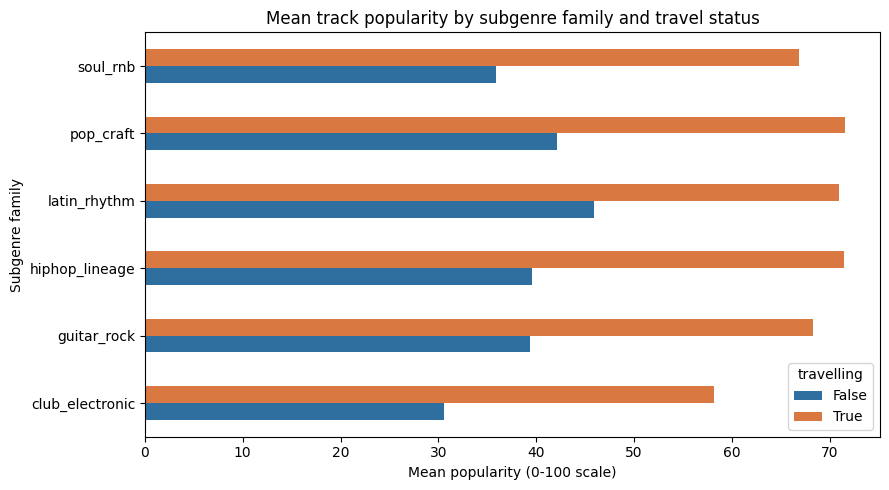

In [179]:
pivot = merged.pivot_table(
    index='family',
    values='track_popularity',
    columns='travelling',
    aggfunc='mean'
)

display(pivot.round(2))

pivot_long = pivot.reset_index().melt(
    id_vars='family',
    var_name='travelling',
    value_name='mean_popularity'
)

display(pivot_long.round(2))

ax = pivot.plot(
    kind='barh',
    figsize=(9, 5),
    color=['#2f6f9f', '#d97941']
)

ax.set(
    title='Mean track popularity by subgenre family and travel status',
    xlabel='Mean popularity (0-100 scale)',
    ylabel='Subgenre family'
)

plt.tight_layout()

plt.show()


### Question 3 answers

**We defined travelling as:** ... **because** ...

**The comparison, with counts:** (paste or describe your summary table)

**What changed when we moved the cut-off:**

**Families too thin to carry the comparison:**

**A better grouping than the supplied families would have been:**

**Do the two groups differ in release year, and what does that do to the popularity result:**


### Interpretation

_250 to 400 words: what you found, what it's resting on, and two things this data can't
tell the curation team._

## Decision log

One line per question. What you decided, and what it cost.

| Question | Decision | What it cost |
|---|---|---|
| 1 · Rows and reach | | |
| 2 · The join | | |
| 3 · Cut-off and comparison | | |

## Tools we used

_Which ones, what for. The condition is that you can explain any line you hand in, and
you're about to present it._

## Before handing in

- [ ] Group number and names in the first cell
- [ ] Restart & Run All, clean kernel, produces this notebook
- [ ] Three questions, in order, prompt comments deleted
- [ ] Decision log filled in
- [ ] Everyone speaks in the video, on a different decision
